In [1]:
import sys
from pathlib import Path

_root = Path.cwd().resolve()
if not (_root / "src").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from src.models import build_and_sample_hbrm
from src.config import *

Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)
Path(POSTERIORS_DIR).mkdir(parents=True, exist_ok=True)

In [2]:
df_train = pd.read_csv(Path(DATA_PROCESSED_DIR) / "markets_train.csv")

categories = sorted(df_train["category_str"].unique().tolist())
cat_to_idx = {c: i for i, c in enumerate(categories)}
n_cats = len(categories)
print(f"Number of categories: {n_cats}")
print(f"Categories: {categories}")
print(f"Training samples: {len(df_train)}")

assert df_train["cat_idx"].max() == n_cats - 1, "cat_idx does not align with category list"
assert df_train["cat_idx"].min() == 0

Number of categories: 12
Categories: ['business', 'chess', 'coronavirus', 'crypto', 'global politics', 'nfts', 'pop-culture', 'science', 'sports', 'ukraine & russia', 'unknown', 'us-current-affairs']
Training samples: 1908


In [3]:
# Subsample test run — verify model compiles and samples before full run
df_small = df_train.sample(500, random_state=42)
trace_test = build_and_sample_hbrm(
    df_small,
    n_cats,
    config={
        "mcmc_draws": 200,
        "mcmc_tune": 200,
        "mcmc_chains": 2,
        "mcmc_target_accept": 0.90,
        "random_seed": 42,
        "save_trace": False,
    },
)
print("Test run successful! Proceeding to full model.")

Sampling HBRM with NUTS...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_alpha, mu_beta, sigma_alpha, sigma_beta, alpha_offset, beta_offset, gamma_vol, gamma_liq, gamma_spr]


Output()

Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 14 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Number of divergences: 0
R-hat range (all sampled vars): [0.9981, 1.0147]
ESS range (ess_bulk): [118.9, 901.6]
save_trace=False — skipping write to hbrm_trace.nc
Test run successful! Proceeding to full model.


In [4]:
trace = build_and_sample_hbrm(
    df_train,
    n_cats,
    config={
        "mcmc_draws": MCMC_DRAWS,
        "mcmc_tune": MCMC_TUNE,
        "mcmc_chains": MCMC_CHAINS,
        "mcmc_target_accept": MCMC_TARGET_ACCEPT,
        "random_seed": RANDOM_SEED,
    },
)
# Trace is also written to outputs/posteriors/hbrm_trace.nc inside build_and_sample_hbrm

Sampling HBRM with NUTS...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, mu_beta, sigma_alpha, sigma_beta, alpha_offset, beta_offset, gamma_vol, gamma_liq, gamma_spr]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 48 seconds.



Number of divergences: 0
R-hat range (all sampled vars): [0.9998, 1.0037]
ESS range (ess_bulk): [1896.6, 15859.4]
Saved trace: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\posteriors\hbrm_trace.nc


In [5]:
summary = az.summary(
    trace,
    var_names=[
        "mu_alpha",
        "mu_beta",
        "sigma_alpha",
        "sigma_beta",
        "gamma_vol",
        "gamma_liq",
        "gamma_spr",
    ],
)
print(summary)

rhat_vals = summary["r_hat"]
print(f"\nMax R-hat: {rhat_vals.max():.4f}")
print(f"All R-hat < 1.01: {(rhat_vals < 1.01).all()}")

n_div = int(trace.sample_stats["diverging"].values.sum())
print(f"Number of divergences: {n_div}")
if n_div > 0:
    print("WARNING: Divergences detected. Consider increasing target_accept to 0.95")

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_alpha    -0.401  0.155  -0.696   -0.119      0.004    0.002    1897.0   
mu_beta      1.378  0.396   0.612    2.117      0.005    0.004    6196.0   
sigma_alpha  0.447  0.120   0.243    0.673      0.002    0.002    2504.0   
sigma_beta   0.402  0.297   0.001    0.931      0.004    0.003    4783.0   
gamma_vol    0.046  0.051  -0.054    0.140      0.001    0.001    9467.0   
gamma_liq   -0.490  0.197  -0.851   -0.124      0.002    0.002    8794.0   
gamma_spr    0.211  0.143  -0.059    0.468      0.002    0.002    7412.0   

             ess_tail  r_hat  
mu_alpha       3756.0    1.0  
mu_beta        5585.0    1.0  
sigma_alpha    4606.0    1.0  
sigma_beta     3113.0    1.0  
gamma_vol      5755.0    1.0  
gamma_liq      5688.0    1.0  
gamma_spr      5183.0    1.0  

Max R-hat: 1.0000
All R-hat < 1.01: True
Number of divergences: 0


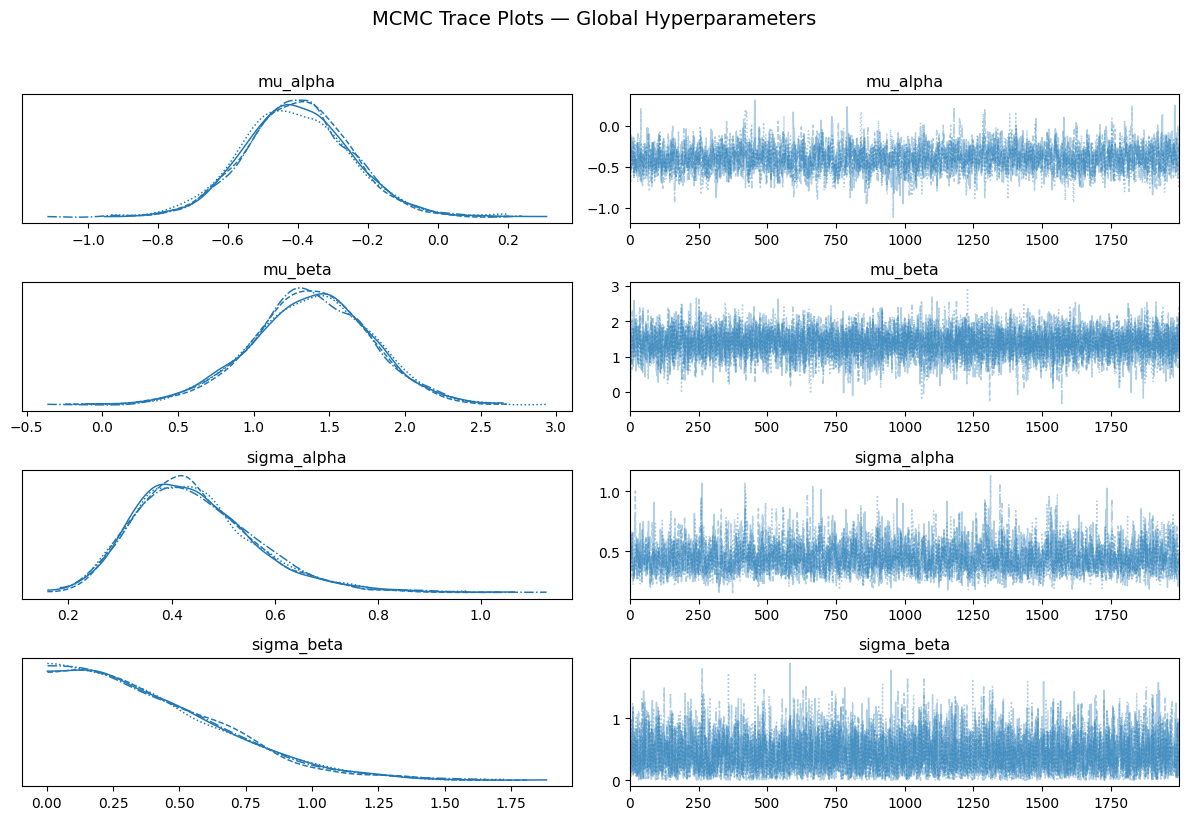

In [6]:
az.plot_trace(trace, var_names=["mu_alpha", "mu_beta", "sigma_alpha", "sigma_beta"])
plt.suptitle("MCMC Trace Plots — Global Hyperparameters", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(Path(FIGURES_DIR) / "08_trace_global.png", dpi=150, bbox_inches="tight")
plt.show()

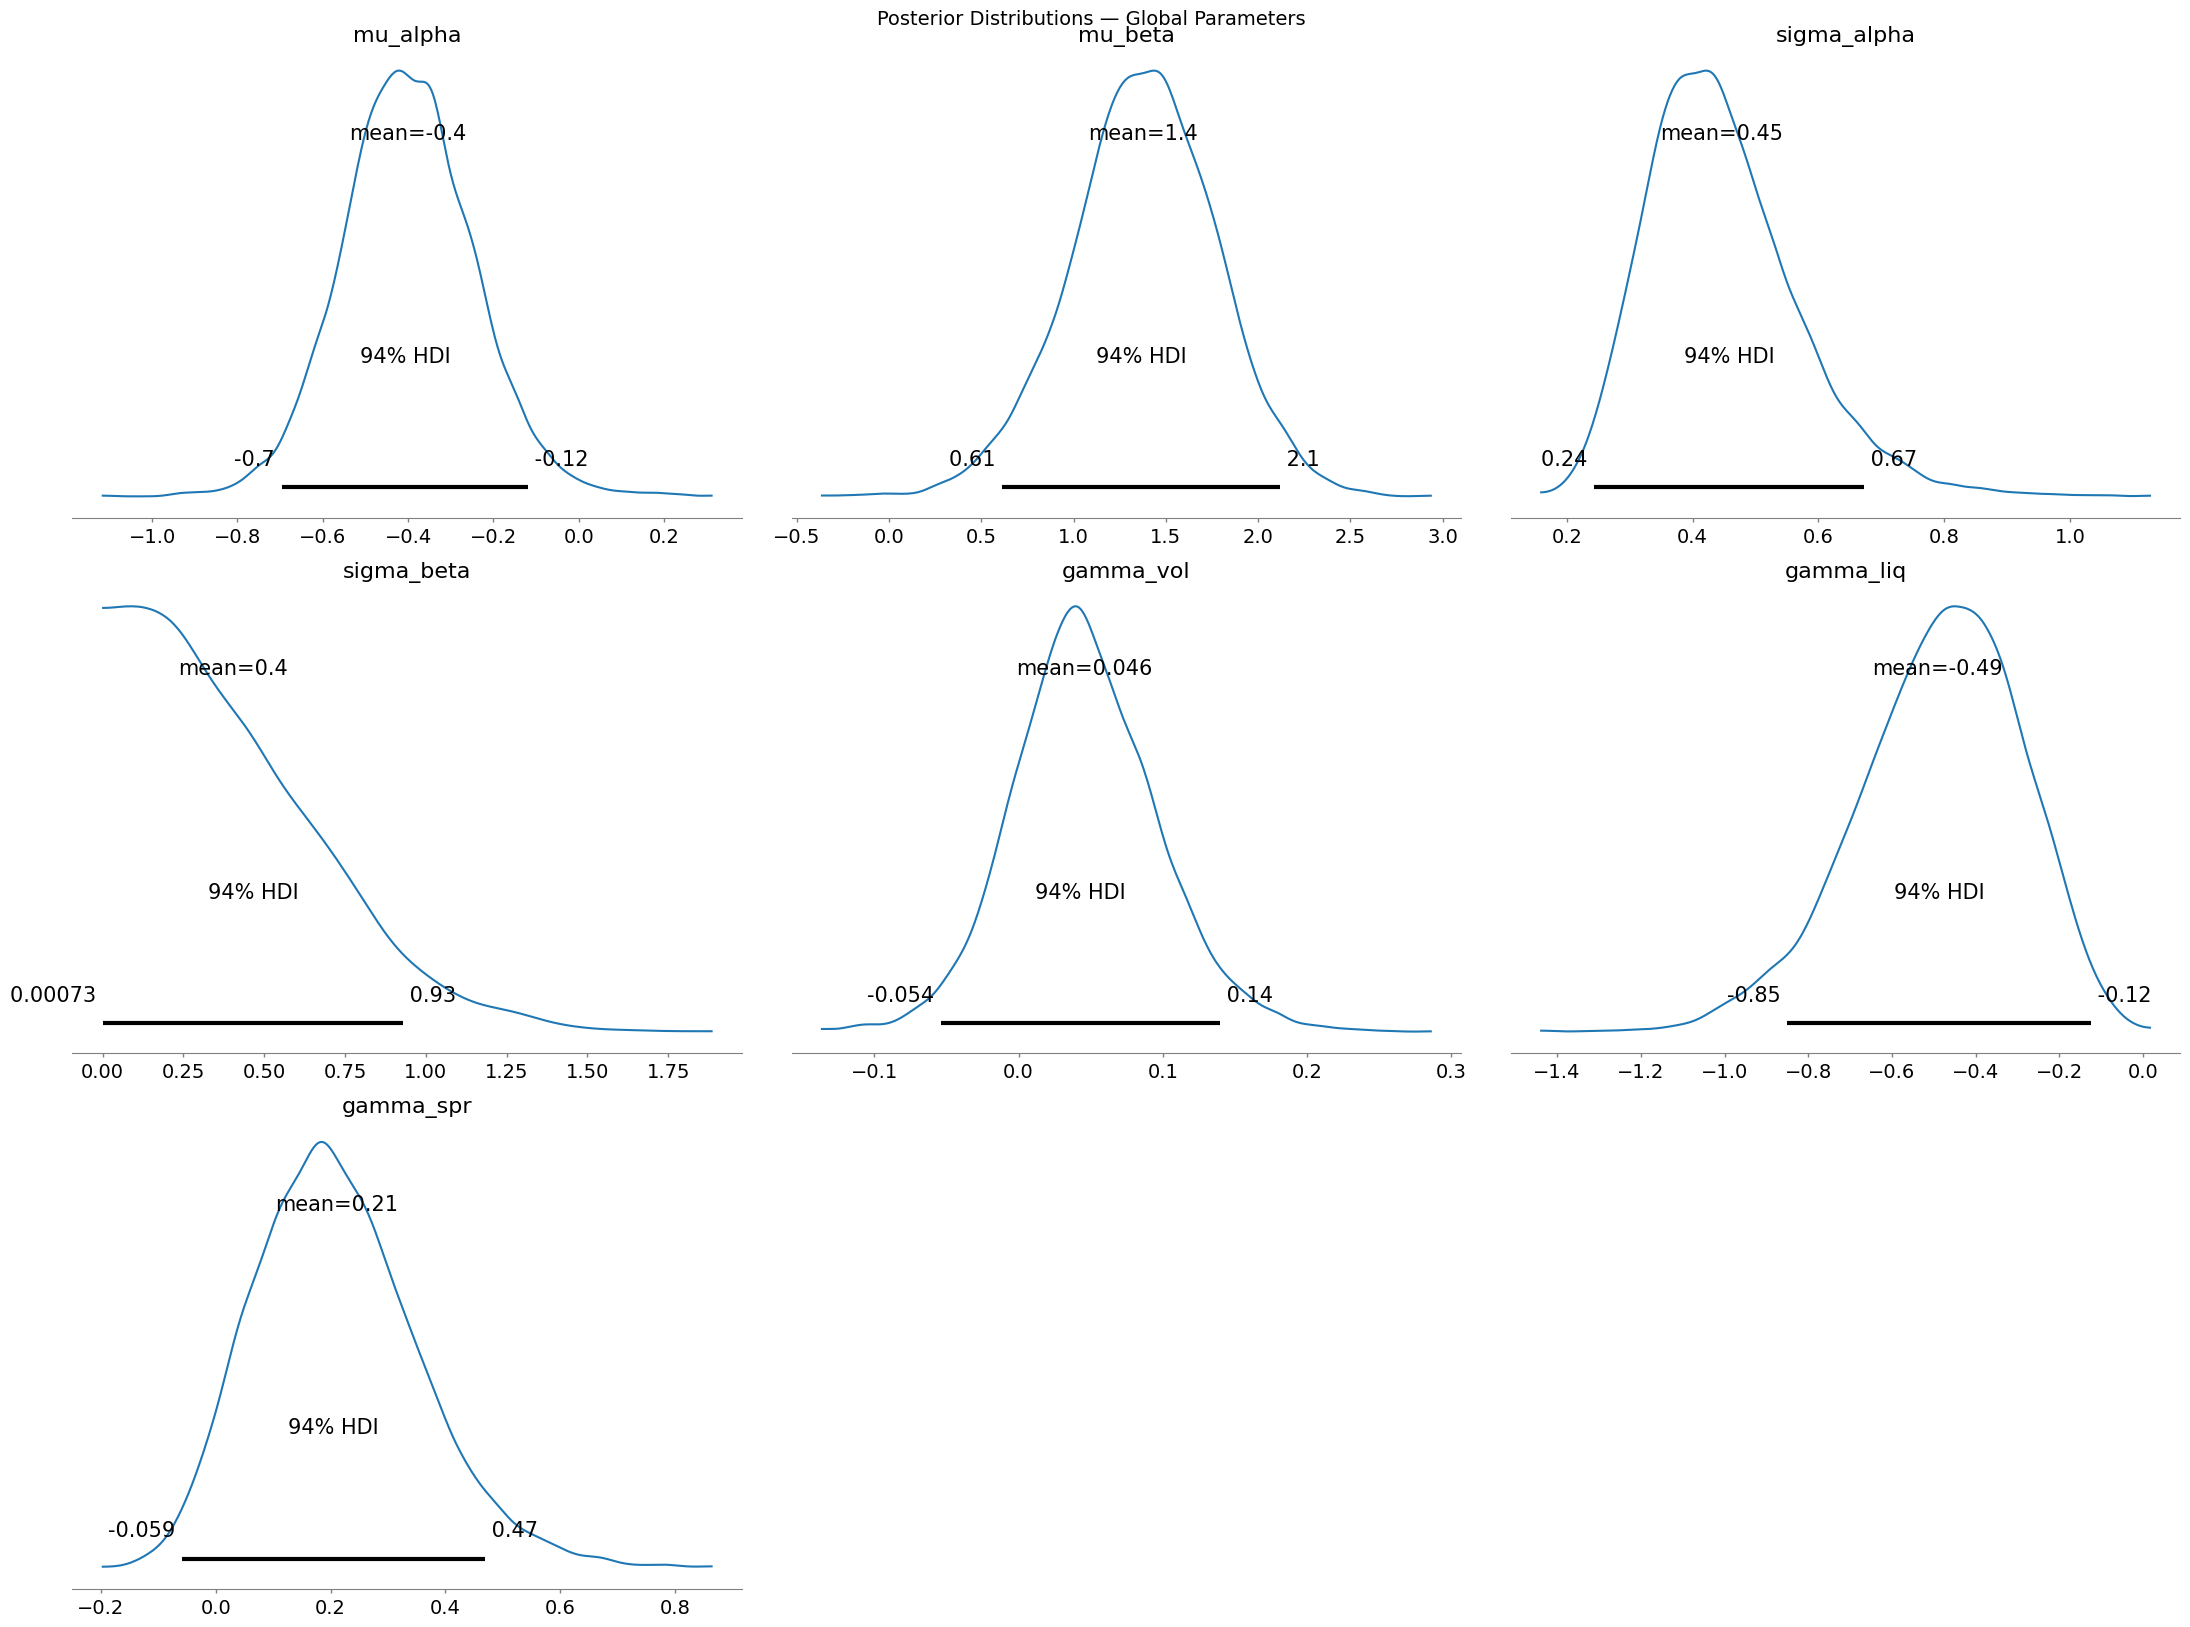

In [7]:
az.plot_posterior(
    trace,
    var_names=[
        "mu_alpha",
        "mu_beta",
        "sigma_alpha",
        "sigma_beta",
        "gamma_vol",
        "gamma_liq",
        "gamma_spr",
    ],
    hdi_prob=0.94,
)
plt.suptitle("Posterior Distributions — Global Parameters", fontsize=14)
plt.tight_layout()
plt.savefig(Path(FIGURES_DIR) / "09_posterior_global.png", dpi=150, bbox_inches="tight")
plt.show()

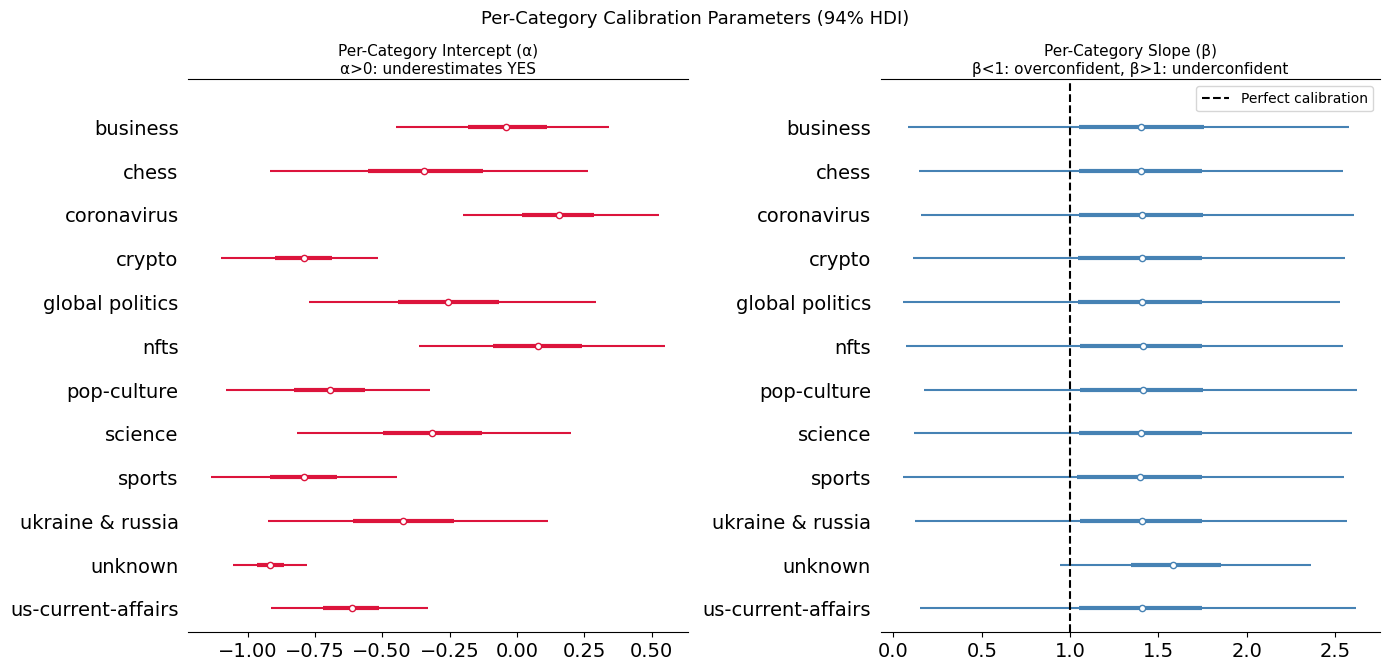

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, n_cats * 0.4 + 2)))

az.plot_forest(
    trace,
    var_names=["alpha"],
    combined=True,
    ax=axes[0],
    hdi_prob=0.94,
    colors="crimson",
)
axes[0].set_title("Per-Category Intercept (α)\nα>0: underestimates YES", fontsize=11)

az.plot_forest(
    trace,
    var_names=["beta"],
    combined=True,
    ax=axes[1],
    hdi_prob=0.94,
    colors="steelblue",
)
axes[1].set_title("Per-Category Slope (β)\nβ<1: overconfident, β>1: underconfident", fontsize=11)
axes[1].axvline(1.0, color="black", linestyle="--", linewidth=1.5, label="Perfect calibration")
axes[1].legend()

yt = axes[0].get_yticklabels()
if len(yt) == len(categories):
    axes[0].set_yticklabels(categories[::-1])
yt2 = axes[1].get_yticklabels()
if len(yt2) == len(categories):
    axes[1].set_yticklabels(categories[::-1])

plt.suptitle("Per-Category Calibration Parameters (94% HDI)", fontsize=13)
plt.tight_layout()
plt.savefig(Path(FIGURES_DIR) / "10_forest_alpha_beta.png", dpi=200, bbox_inches="tight")
plt.show()